# Two-Player Shapley: Motif Syntax vs Background

For each sequence we define two players:
- **Motif syntax**: all annotated motifs treated as a single unit
- **Background**: everything outside the motif regions

Four coalition values:
| Coalition | Construction |
|-----------|-------------|
| `v({})` | Fully dinuc-shuffled sequence (baseline) |
| `v({motif})` | Original motifs placed into a shuffled background |
| `v({bg})` | Shuffled motifs placed into the original background |
| `v({motif, bg})` | Wild-type sequence |

Shapley values:
- `φ(motif) = ½[v({m}) - v({})] + ½[v({m,bg}) - v({bg})]`
- `φ(bg)    = ½[v({bg}) - v({})] + ½[v({m,bg}) - v({m})]`

In [37]:
import os, sys, copy, re, ast
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.fx as fx
import matplotlib.pyplot as plt

from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle, multisubstitute
from tangermeme.predict import predict

REPO = '/grid/wsbs/home_norepl/pmantill/Motif_Swap_Experiments/Replicating_Motif_Swap_Manuscript'
DATA_DIR = os.path.join(os.path.dirname(REPO), 'Motif_Context_SII', 'data')
RESULTS_DIR = os.path.join(os.path.dirname(REPO), 'Motif_Context_SII', 'results')

In [38]:
# Load manually curated clean hits for both Dev and Hk
HEADS = {
    'Dev': {'head_idx': 0, 'hits_prefix': '{bin}_clean_hits_seq',
            'real_col': 'real_Dev', 'pred_col': 'pred_Dev',
            'lib_subdir': 'Dev_full_data'},
    'Hk':  {'head_idx': 1, 'hits_prefix': '{bin}_clean_hits_Hk_seq',
            'real_col': 'real_Hk',  'pred_col': 'pred_Hk',
            'lib_subdir': 'Hk_full_data'},
}

hits = {}       # hits[head][bin] = DataFrame
hits_byseq = {} # hits[head][bin][seq_name] = DataFrame
valid_seqs = {} # valid_seqs[head][bin] = array of seq names

for head, cfg in HEADS.items():
    hits[head] = {}
    hits_byseq[head] = {}
    valid_seqs[head] = {}
    for bin_name in ['high', 'mid', 'low']:
        fname = cfg['hits_prefix'].format(bin=bin_name) + '.csv'
        df = pd.read_csv(os.path.join(DATA_DIR, fname))
        hits[head][bin_name] = df
        hits_byseq[head][bin_name] = dict(tuple(df.groupby('sequence_name')))
        valid_seqs[head][bin_name] = df['sequence_name'].unique()
        print(f'{head} {bin_name}: {len(df)} hits, {df.sequence_name.nunique()} sequences')

Dev high: 295 hits, 110 sequences
Dev mid: 233 hits, 110 sequences
Dev low: 222 hits, 110 sequences
Hk high: 257 hits, 110 sequences
Hk mid: 278 hits, 110 sequences
Hk low: 231 hits, 110 sequences


In [39]:
# Load binned library dataframes for both Dev and Hk

_DTYPE_DEVICE_RE = re.compile(r",(?:\s*dtype\s*=\s*[\w\.]+|\s*device\s*=\s*[^)\]]+)\s*\)?\s*$")

def _extract_bracket_payload(s: str) -> str:
    s = s.strip()
    if s.startswith("tensor(") and s.endswith(")"):
        s = s[len("tensor("):-1].strip()
    start = s.find('[')
    if start < 0:
        raise ValueError("No bracketed payload in string")
    s = _DTYPE_DEVICE_RE.sub("", s)
    depth = 0
    end = None
    for i, ch in enumerate(s[start:], start=start):
        if ch == '[': depth += 1
        elif ch == ']':
            depth -= 1
            if depth == 0:
                end = i + 1
                break
    if end is None:
        raise ValueError("Unbalanced brackets in payload")
    return s[start:end]

def str_tensor_to_torch(s, dtype=None, device=None):
    if s is None: return None
    payload = _extract_bracket_payload(str(s))
    data = ast.literal_eval(payload)
    return torch.tensor(data, dtype=dtype or torch.float32, device=device)

def restore_tensor_columns(df, cols, dtypes, device=None):
    for col in cols:
        if col in df.columns:
            dt = dtypes.get(col, torch.float32)
            df[col] = [str_tensor_to_torch(v, dtype=dt, device=device)
                       if isinstance(v, str) else v for v in df[col].tolist()]
    return df

COL_DTYPES = {"ohe_seq": torch.int8}

# bin_data[head][bin] = {'ohe': array of tensors, 'df': DataFrame}
bin_data = {}
for head, cfg in HEADS.items():
    bin_data[head] = {}
    for bin_name in ['high', 'mid', 'low']:
        df = pd.read_csv(os.path.join(REPO, 'experimental_library_generation',
                                       'Binned_libraries', cfg['lib_subdir'], f'{bin_name}_df.csv'))
        df = restore_tensor_columns(df, cols=["ohe_seq"], dtypes=COL_DTYPES)
        bin_data[head][bin_name] = {'ohe': df["ohe_seq"].values, 'df': df}
        print(f'{head} {bin_name}: {len(df)} seqs, OHE shape = {df["ohe_seq"].iloc[0].shape}')

Dev high: 3000 seqs, OHE shape = torch.Size([4, 249])
Dev mid: 3000 seqs, OHE shape = torch.Size([4, 249])
Dev low: 3000 seqs, OHE shape = torch.Size([4, 249])
Hk high: 3000 seqs, OHE shape = torch.Size([4, 249])
Hk mid: 3000 seqs, OHE shape = torch.Size([4, 249])
Hk low: 3000 seqs, OHE shape = torch.Size([4, 249])


In [40]:
# Rebuild DeepSTARR student model architecture from state dict (no evoaug_utils needed)
# Architecture reverse-engineered from distill_EvoAug2.py + checkpoint shapes

class DeepSTARRBackbone(nn.Module):
    """DeepSTARR CNN backbone (4 conv blocks + 2 FC layers)."""
    def __init__(self):
        super().__init__()
        # Conv block 1: (4, 7) -> 256 filters
        self.conv1_filters = nn.Parameter(torch.empty(256, 4, 7))
        self.batchnorm1 = nn.BatchNorm1d(256)
        self.activation1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool1d(2)
        # Conv block 2: 256 -> 60, kernel 3
        self.conv2_filters = nn.Parameter(torch.empty(60, 256, 3))
        self.batchnorm2 = nn.BatchNorm1d(60)
        self.activation = nn.ReLU()
        self.maxpool2 = nn.MaxPool1d(2)
        # Conv block 3: 60 -> 60, kernel 5
        self.conv3_filters = nn.Parameter(torch.empty(60, 60, 5))
        self.batchnorm3 = nn.BatchNorm1d(60)
        self.maxpool3 = nn.MaxPool1d(2)
        # Conv block 4: 60 -> 120, kernel 3
        self.conv4_filters = nn.Parameter(torch.empty(120, 60, 3))
        self.batchnorm4 = nn.BatchNorm1d(120)
        self.maxpool4 = nn.MaxPool1d(2)
        # FC layers
        self.flatten = nn.Flatten()
        self.fc5 = nn.Linear(1800, 256)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.fc6 = nn.Linear(256, 256)
        self.batchnorm6 = nn.BatchNorm1d(256)
        self.dropout4 = nn.Dropout(0.4)

class UncertaintyAwareStudent(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = DeepSTARRBackbone()
        self.mean_head = nn.Linear(256, 2)
        self.uncertainty_head = nn.Linear(256, 2)
    
    def forward(self, x):
        cnn = torch.conv1d(x, self.backbone.conv1_filters, stride=1, padding="same")
        cnn = self.backbone.batchnorm1(cnn)
        cnn = self.backbone.activation1(cnn)
        cnn = self.backbone.maxpool1(cnn)
        cnn = torch.conv1d(cnn, self.backbone.conv2_filters, stride=1, padding="same")
        cnn = self.backbone.batchnorm2(cnn)
        cnn = self.backbone.activation(cnn)
        cnn = self.backbone.maxpool2(cnn)
        cnn = torch.conv1d(cnn, self.backbone.conv3_filters, stride=1, padding="same")
        cnn = self.backbone.batchnorm3(cnn)
        cnn = self.backbone.activation(cnn)
        cnn = self.backbone.maxpool3(cnn)
        cnn = torch.conv1d(cnn, self.backbone.conv4_filters, stride=1, padding="same")
        cnn = self.backbone.batchnorm4(cnn)
        cnn = self.backbone.activation(cnn)
        cnn = self.backbone.maxpool4(cnn)
        cnn = self.backbone.flatten(cnn)
        cnn = self.backbone.fc5(cnn)
        cnn = self.backbone.batchnorm5(cnn)
        cnn = self.backbone.activation(cnn)
        cnn = self.backbone.dropout4(cnn)
        cnn = self.backbone.fc6(cnn)
        cnn = self.backbone.batchnorm6(cnn)
        cnn = self.backbone.activation(cnn)
        cnn = self.backbone.dropout4(cnn)
        return {
            'mean': self.mean_head(cnn),
            'uncertainty': nn.functional.softplus(self.uncertainty_head(cnn)),
        }

# Load from .ckpt state dict
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dir = "/grid/wsbs/home_norepl/pmantill/Trained_Model_Zoo/EvoAug_Distilled_Student_Model"
ckpt_path = os.path.join(model_dir, "EvoAug_student_model.ckpt")

pytorch_model = UncertaintyAwareStudent()
state_dict = torch.load(ckpt_path, map_location='cpu', weights_only=True)
pytorch_model.load_state_dict(state_dict)
pytorch_model = pytorch_model.to(device).eval()

# Head indices: 0=Dev, 1=Hk
DEV_IDX = 0
HK_IDX = 1
print(f"Model loaded on {device}")

Model loaded on cuda


In [41]:
def get_spacings(regions):
    """Compute inter-motif spacings from sorted start/end regions."""
    starts = regions['start'].to_numpy()
    ends = regions['end'].to_numpy()
    spacings = (starts[1:] - ends[:-1]).astype(int).tolist() if len(starts) > 1 else []
    return spacings

def build_coalitions(ohe, regions, n_shuf=10):
    """
    Build the 4 coalition sequences for a 2-player Shapley game.
    
    Each coalition is marginalized over its own independent set of
    dinucleotide shuffles so that the expectation is taken before
    the Shapley decomposition.
    
    Returns dict with keys: 'wt', 'empty', 'motif_only', 'bg_only'
    Each value is a tensor of shape (n_shuf, C, L) except 'wt' which is (1, C, L).
    """
    starts = regions['start'].to_numpy()
    ends = regions['end'].to_numpy()
    spacings = get_spacings(regions)
    
    ohe_batch = ohe.unsqueeze(0)  # (1, C, L)
    
    def _shuffle_batch(n):
        """Generate n independent dinucleotide shuffles."""
        shuf = dinucleotide_shuffle(ohe_batch, n=n)
        if shuf.ndim == 4:
            if shuf.shape[0] == n:
                shuf = shuf.squeeze(1)
            elif shuf.shape[1] == n:
                shuf = shuf.squeeze(0)
        return shuf  # (n, C, L)
    
    # Independent shuffle sets for each coalition
    shuf_empty = _shuffle_batch(n_shuf)      # for v({})
    shuf_motif = _shuffle_batch(n_shuf)      # for v({motif}) — independent bg shuffles
    shuf_bg    = _shuffle_batch(n_shuf)      # for v({bg})    — independent motif shuffles
    
    # Extract original motifs
    orig_motifs = [ohe[:, int(s):int(e)].unsqueeze(0) for s, e in zip(starts, ends)]
    
    motif_only_list = []  # v({motif}): orig motifs into shuffled bg
    bg_only_list = []     # v({bg}): shuffled motifs into orig bg
    
    for i in range(n_shuf):
        # v({motif}): place original motifs into independently shuffled background
        motif_in_shuf = multisubstitute(
            shuf_motif[i].unsqueeze(0), orig_motifs,
            spacing=spacings, start=int(starts[0])
        )
        motif_only_list.append(motif_in_shuf.squeeze(0))
        
        # v({bg}): place independently shuffled motifs into original background
        shuf_motifs_i = [shuf_bg[i, :, int(s):int(e)].unsqueeze(0)
                         for s, e in zip(starts, ends)]
        shuf_in_orig = multisubstitute(
            ohe_batch, shuf_motifs_i,
            spacing=spacings, start=int(starts[0])
        )
        bg_only_list.append(shuf_in_orig.squeeze(0))
    
    return {
        'wt': ohe_batch,                          # (1, C, L)
        'empty': shuf_empty,                       # (n_shuf, C, L)
        'motif_only': torch.stack(motif_only_list), # (n_shuf, C, L)
        'bg_only': torch.stack(bg_only_list),       # (n_shuf, C, L)
    }

print("Coalition builder ready — independent shuffles per coalition")

Coalition builder ready — independent shuffles per coalition


In [42]:
# Run 2-player Shapley game for both Dev and Hk
N_SHUF = 10
BATCH_SIZE = 256
n_seqs = 100  # per bin

rows = []

for head, cfg in HEADS.items():
    head_idx = cfg['head_idx']
    real_col = cfg['real_col']
    pred_col = cfg['pred_col']
    
    print(f"\n{'='*50}")
    print(f"Processing {head} (head_idx={head_idx})")
    print(f"{'='*50}")
    
    for bin_name in ['high', 'mid', 'low']:
        ohe_list = bin_data[head][bin_name]['ohe']
        seqs = valid_seqs[head][bin_name][:n_seqs]
        print(f"\n--- {head} {bin_name} bin: {len(seqs)} sequences ---")
        
        for idx, seq_name in enumerate(seqs):
            ohe = ohe_list[seq_name].float()  # (C, L)
            regions = (hits_byseq[head][bin_name][seq_name][['start', 'end']]
                       .sort_values('start').reset_index(drop=True))
            
            coal = build_coalitions(ohe, regions, n_shuf=N_SHUF)
            
            all_seqs = torch.cat([
                coal['wt'],          # 1
                coal['empty'],       # N_SHUF
                coal['motif_only'],  # N_SHUF
                coal['bg_only'],     # N_SHUF
            ], dim=0)
            
            with torch.no_grad():
                preds = predict(pytorch_model, all_seqs, batch_size=BATCH_SIZE,
                               func=lambda x: x['mean'])[:, head_idx].numpy()
            
            v_wt = preds[0]
            v_empty = preds[1:1+N_SHUF].mean()
            v_motif = preds[1+N_SHUF:1+2*N_SHUF].mean()
            v_bg = preds[1+2*N_SHUF:1+3*N_SHUF].mean()
            
            phi_motif = 0.5 * (v_motif - v_empty) + 0.5 * (v_wt - v_bg)
            phi_bg = 0.5 * (v_bg - v_empty) + 0.5 * (v_wt - v_motif)
            sii = v_wt - v_motif - v_bg + v_empty
            
            seq_hits = hits_byseq[head][bin_name][seq_name].iloc[0]
            
            rows.append({
                'head': head,
                'bin': bin_name,
                'sequence_name': seq_name,
                'real_activity': seq_hits[real_col],
                'pred_activity': seq_hits[pred_col],
                'v_wt': v_wt,
                'v_empty': v_empty,
                'v_motif_only': v_motif,
                'v_bg_only': v_bg,
                'phi_motif': phi_motif,
                'phi_bg': phi_bg,
                'sii_motif_bg': sii,
                'n_motifs': len(regions),
            })
            
            if (idx + 1) % 25 == 0:
                print(f"  processed {idx+1}/{len(seqs)}")

shapley_df = pd.DataFrame(rows)
print(f"\nDone: {len(shapley_df)} sequences total")
shapley_df.head()


Processing Dev (head_idx=0)

--- Dev high bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Dev mid bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Dev low bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

Processing Hk (head_idx=1)

--- Hk high bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Hk mid bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Hk low bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

Done: 600 sequences total


,head,bin,sequence_name,real_activity,pred_activity,v_wt,v_empty,v_motif_only,v_bg_only,phi_motif,phi_bg,sii_motif_bg,n_motifs
0,Dev,high,0,2.712676,2.012777,2.012741,0.268975,1.044630,0.983356,0.902520,0.841246,0.253730,2
1,Dev,high,1,2.698660,2.229675,2.229769,0.353665,1.018731,0.237985,1.328425,0.547679,1.326718,2
2,Dev,high,3,2.632013,2.401619,2.401401,0.707148,1.299716,1.730482,0.631744,1.062509,0.078351,1
3,Dev,high,4,1.167345,2.650553,2.650973,-0.165377,0.867034,1.589255,1.047064,1.769286,0.029307,1
4,Dev,high,5,2.634589,2.986293,2.986579,0.873440,1.511697,1.555104,1.034867,1.078273,0.793218,3


In [43]:
# Save results
os.makedirs(RESULTS_DIR, exist_ok=True)
shapley_df.to_csv(os.path.join(RESULTS_DIR, 'two_player_shapley.csv'), index=False)
print(f"Saved to {RESULTS_DIR}/two_player_shapley.csv")

Saved to /grid/wsbs/home_norepl/pmantill/Motif_Swap_Experiments/Motif_Context_SII/results/two_player_shapley.csv


## Visualize Shapley decomposition

In [44]:
# Compute derived columns
shapley_df['total_effect'] = shapley_df['v_wt'] - shapley_df['v_empty']
shapley_df['frac_motif'] = shapley_df['phi_motif'] / shapley_df['total_effect']
shapley_df['frac_bg'] = shapley_df['phi_bg'] / shapley_df['total_effect']
shapley_df['context_over_motif'] = shapley_df['phi_bg'] / shapley_df['phi_motif']

bin_colors = {'high': '#D32F2F', 'mid': '#FFA000', 'low': '#1976D2'}
bin_order = ['high', 'mid', 'low']
bin_labels = ['High', 'Mid', 'Low']

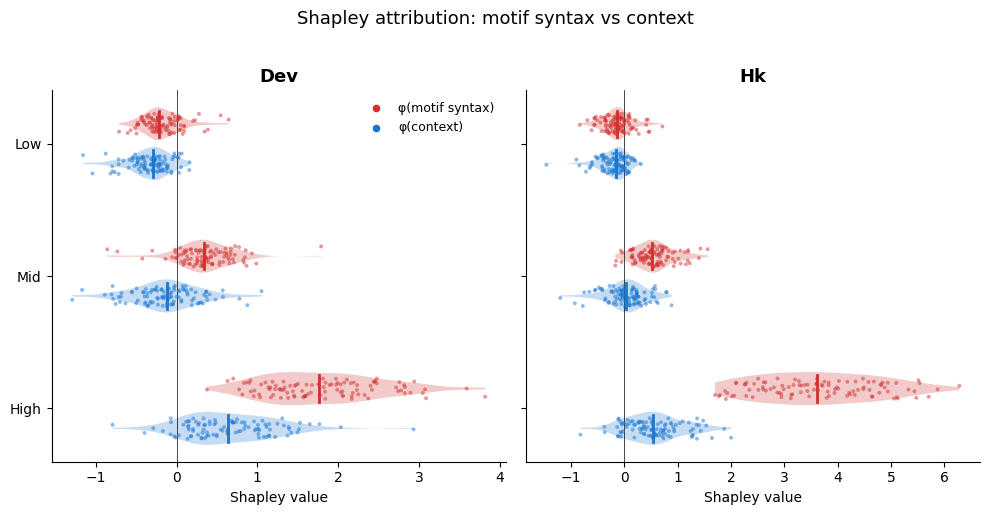

In [50]:
# ── Fig 1: Horizontal violin + swarm — φ(motif) vs φ(context) per bin, Dev & Hk ──
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]
    y_pos = np.arange(len(bin_order))

    for col_name, color, y_offset, label in [
        ('phi_motif', '#D32F2F', 0.15, 'φ(motif syntax)'),
        ('phi_bg',    '#1976D2', -0.15, 'φ(context)'),
    ]:
        data = [sub_h[sub_h['bin'] == b][col_name].values for b in bin_order]

        # Horizontal violins
        vp = ax.violinplot(data, positions=y_pos + y_offset, vert=False,
                           showmedians=False, showextrema=False, widths=0.25)
        for body in vp['bodies']:
            body.set_facecolor(color)
            body.set_alpha(0.25)
            body.set_edgecolor('none')

        # Individual points with jitter
        for i, d in enumerate(data):
            jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(d))
            ax.scatter(d, y_pos[i] + y_offset + jitter, s=8, alpha=0.5,
                       color=color, edgecolors='none', zorder=3)

        # Median line
        for i, d in enumerate(data):
            med = np.median(d)
            ax.plot([med, med], [y_pos[i] + y_offset - 0.1, y_pos[i] + y_offset + 0.1],
                    color=color, lw=2, zorder=4)

        # Dummy for legend
        ax.scatter([], [], s=20, color=color, label=label)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bin_labels)
    ax.set_xlabel('Shapley value')
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.axvline(0, c='k', lw=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axes[0]:
        ax.legend(frameon=False, fontsize=9)

plt.suptitle('Shapley attribution: motif syntax vs context', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_mean_shapley_violins.png'), dpi=200, bbox_inches='tight')
plt.show()

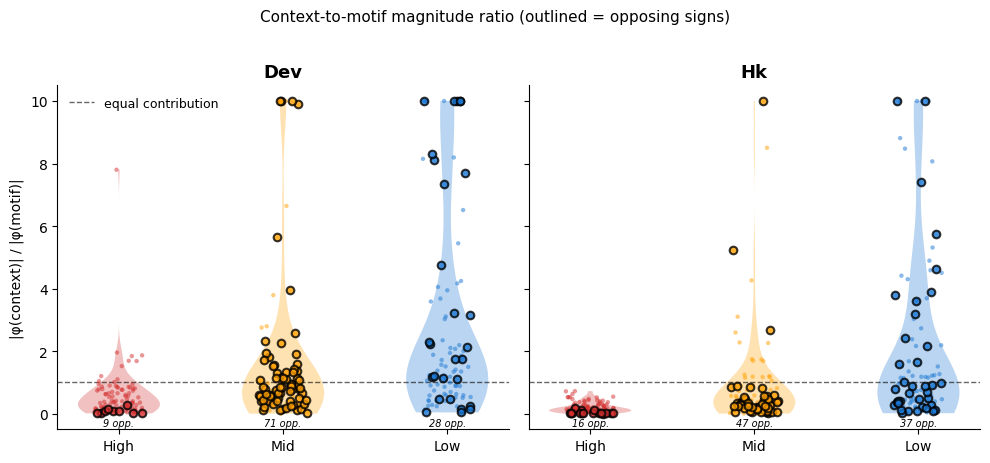

In [49]:
# ── Fig 3: |φ(context)| / |φ(motif)| ratio — violin + swarm by bin ──
# Points where φ(motif) and φ(context) have opposite signs get bold outlines

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head].copy()
    sub_h['mag_ratio'] = sub_h['phi_bg'].abs() / sub_h['phi_motif'].abs()
    sub_h['opposing'] = (sub_h['phi_motif'] * sub_h['phi_bg']) < 0

    data = [sub_h[sub_h['bin'] == b]['mag_ratio'].clip(0, 10).values
            for b in bin_order]

    vp = ax.violinplot(data, positions=range(len(bin_order)),
                       showmedians=False, showextrema=False)
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(list(bin_colors.values())[i])
        body.set_alpha(0.3)
        body.set_edgecolor('none')

    # Overlay individual points with jitter
    for i, b in enumerate(bin_order):
        sub_b = sub_h[sub_h['bin'] == b]
        vals = sub_b['mag_ratio'].clip(0, 10).values
        opp = sub_b['opposing'].values
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))

        # Concordant points (both pos or both neg)
        mask_conc = ~opp
        ax.scatter(i + jitter[mask_conc], vals[mask_conc], s=10, alpha=0.5,
                   color=bin_colors[b], edgecolors='none', zorder=3)

        # Opposing sign points — same color dot with bold black outline
        mask_opp = opp
        if mask_opp.any():
            ax.scatter(i + jitter[mask_opp], vals[mask_opp], s=30, alpha=0.8,
                       color=bin_colors[b], edgecolors='k', linewidths=1.5,
                       zorder=5)

    ax.axhline(1, c='k', lw=1, ls='--', alpha=0.6, label='equal contribution')
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_labels)
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('|φ(context)| / |φ(motif)|')
        ax.legend(frameon=False, fontsize=9, loc='upper left')

    # Annotate count of opposing-sign sequences
    for i, b in enumerate(bin_order):
        sub_b = sub_h[sub_h['bin'] == b]
        n_opp = sub_b['opposing'].sum()
        if n_opp > 0:
            ax.annotate(f'{n_opp} opp.', xy=(i, 0), xytext=(i, -0.4),
                        fontsize=7, ha='center', color='k', fontstyle='italic')

plt.suptitle('Context-to-motif magnitude ratio (outlined = opposing signs)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3_context_motif_ratio.png'), dpi=200, bbox_inches='tight')
plt.show()

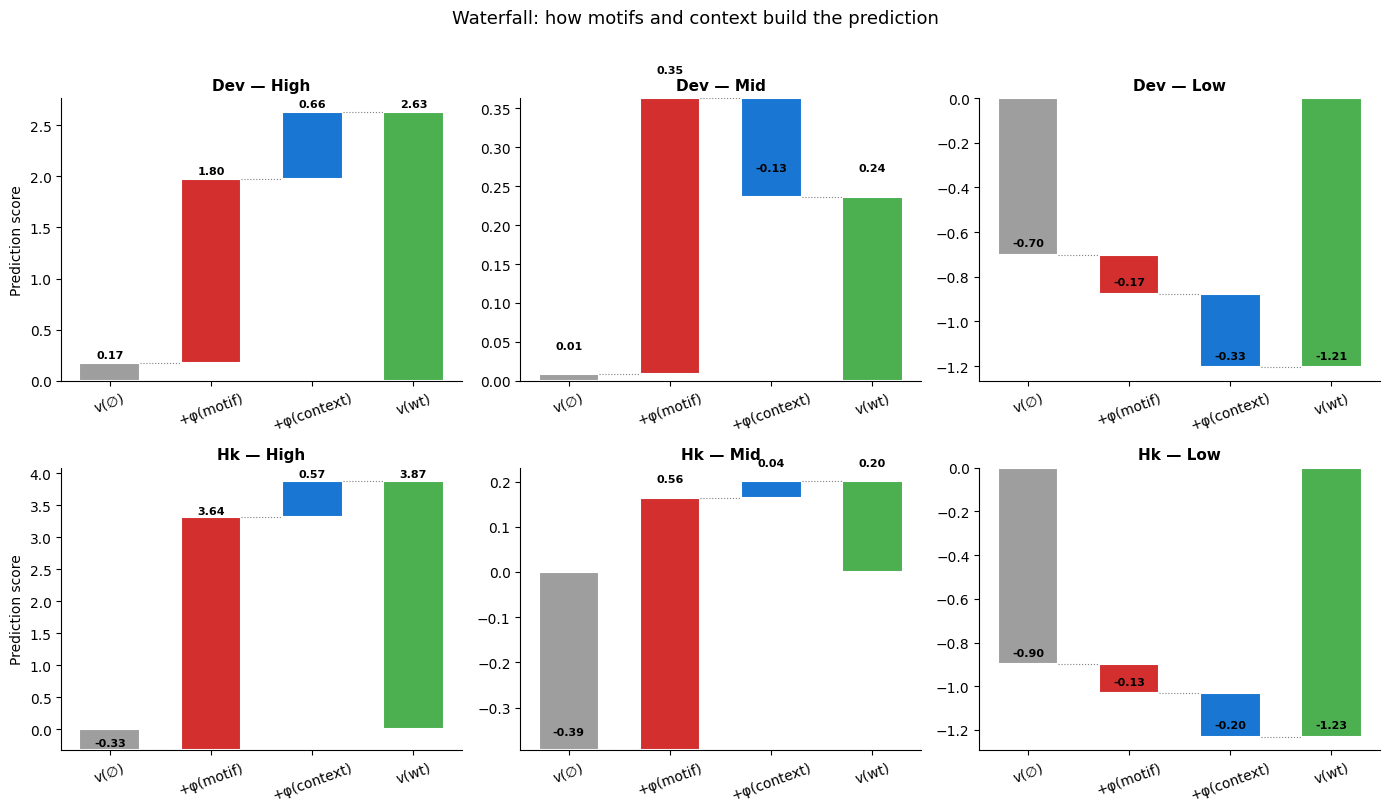

In [47]:
# ── Fig 4: Waterfall decomposition — v(∅) → +φ(motif) → +φ(bg) → v(wt) ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row, head in enumerate(['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]
    for col, bin_name in enumerate(['high', 'mid', 'low']):
        ax = axes[row, col]
        sub = sub_h[sub_h['bin'] == bin_name]
        
        v_empty = sub['v_empty'].mean()
        phi_m = sub['phi_motif'].mean()
        phi_b = sub['phi_bg'].mean()
        v_wt = sub['v_wt'].mean()
        
        labels = ['v(∅)', '+φ(motif)', '+φ(context)', 'v(wt)']
        bottoms = [0, v_empty, v_empty + phi_m, 0]
        heights = [v_empty, phi_m, phi_b, v_wt]
        colors_w = ['#9E9E9E', '#D32F2F', '#1976D2', '#4CAF50']
        
        bars = ax.bar(labels, heights, bottom=bottoms, color=colors_w,
                      width=0.6, edgecolor='white', linewidth=1.5)
        
        # Connector lines between waterfall steps
        for j in range(len(labels) - 1):
            top_j = bottoms[j] + heights[j]
            ax.plot([j + 0.3, j + 0.7], [top_j, top_j],
                    c='k', lw=0.8, ls=':', alpha=0.5)
        
        # Value annotations
        for j, (b, h) in enumerate(zip(bottoms, heights)):
            ax.text(j, b + h + 0.03, f'{h:.2f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
        
        ax.set_title(f'{head} — {bin_name.capitalize()}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Prediction score' if col == 0 else '')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', rotation=20)

plt.suptitle('Waterfall: how motifs and context build the prediction', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig4_waterfall.png'), dpi=200, bbox_inches='tight')
plt.show()

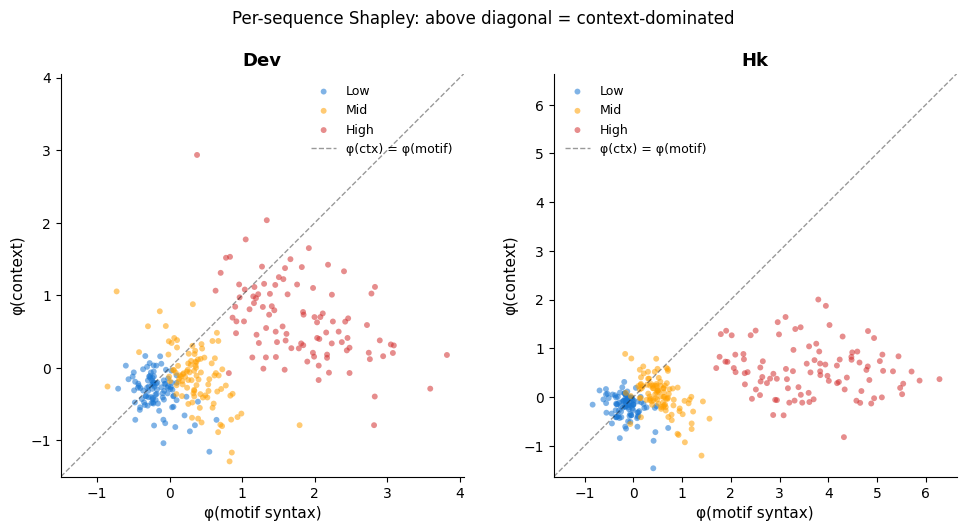

In [48]:
# ── Fig 5: Per-sequence φ(context) vs φ(motif) scatter with diagonal ──
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]
    
    for b in ['low', 'mid', 'high']:
        sub = sub_h[sub_h['bin'] == b]
        ax.scatter(sub['phi_motif'], sub['phi_bg'], s=18, alpha=0.55,
                   color=bin_colors[b], label=b.capitalize(), edgecolors='none')
    
    # Identity line (equal contribution)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.4, label='φ(ctx) = φ(motif)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    
    ax.set_xlabel('φ(motif syntax)', fontsize=11)
    ax.set_ylabel('φ(context)', fontsize=11)
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Per-sequence Shapley: above diagonal = context-dominated',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig5_motif_vs_context_scatter.png'), dpi=200, bbox_inches='tight')
plt.show()